# 1. Bootstrap Validation

## Objective

The previous notebook evaluated the experiment using classical statistical methods, including hypothesis testing, confidence intervals, and effect size.

This notebook validates those findings using **bootstrapping**, a non-parametric resampling technique that estimates the sampling distribution directly from the observed data.

Unlike classical hypothesis tests, bootstrapping makes fewer assumptions about the underlying population and provides an intuitive way to quantify the uncertainty of the estimated retention difference.

# 2. Bootstrap Fundamentals

## What is Bootstrapping?

Bootstrapping is a resampling technique that repeatedly draws random samples **with replacement** from the observed dataset.

Each bootstrap sample has the same size as the original dataset. By computing the statistic of interest across thousands of resampled datasets, we can approximate its sampling distribution.

In this project, bootstrapping is used to estimate the distribution of the difference in retention rates between the two experiment groups.

## Why use Bootstrapping?

- Makes minimal assumptions about the underlying population.
- Estimates uncertainty directly from the observed data.
- Provides an independent validation of the classical statistical results.
- Widely used in A/B testing and experimentation.

# 3. One-Day Retention Bootstrap

## Objective

Estimate the sampling distribution of the one-day retention difference by repeatedly resampling the experiment data.

This analysis serves as a robustness check for the conclusions obtained from the classical hypothesis test.

### 3.1 Prepare the Data

Separate the one-day retention outcomes for the control and treatment groups.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from scipy.stats import chisquare

In [2]:
df = pd.read_csv("../data/cleaned/cookie_cats_cleaned.csv")

In [4]:
import numpy as np
import matplotlib.pyplot as plt

gate30 = df[df["version"] == "gate_30"]["retention_1"]
gate40 = df[df["version"] == "gate_40"]["retention_1"]

print(len(gate30))
print(len(gate40))

44700
45489


### 3.2 Bootstrap Sampling

Generate 10,000 bootstrap samples by resampling each experiment group with replacement.

For every bootstrap iteration:

1. Draw a random sample (with replacement) from each experiment group.
2. Compute the one-day retention rate for both groups.
3. Calculate the retention difference (gate_30 − gate_40).
4. Store the difference for later analysis.

The resulting distribution approximates the sampling distribution of the retention difference.

In [5]:
bootstrap_diffs_1 = []

n_iterations = 10000

for _ in range(n_iterations):

    sample30 = gate30.sample(
        n=len(gate30),
        replace=True
    )

    sample40 = gate40.sample(
        n=len(gate40),
        replace=True
    )

    retention30 = sample30.mean()

    retention40 = sample40.mean()

    diff = retention30 - retention40

    bootstrap_diffs_1.append(diff)

bootstrap_diffs_1 = np.array(bootstrap_diffs_1)

print("Bootstrap samples generated:", len(bootstrap_diffs_1))

Bootstrap samples generated: 10000


### 3.3 Visualize the Bootstrap Distribution

Visualize the distribution of the bootstrapped retention differences to understand the variability of the estimated treatment effect.

The center of the distribution represents the average retention difference observed across the simulated experiments, while the spread reflects the sampling variability.

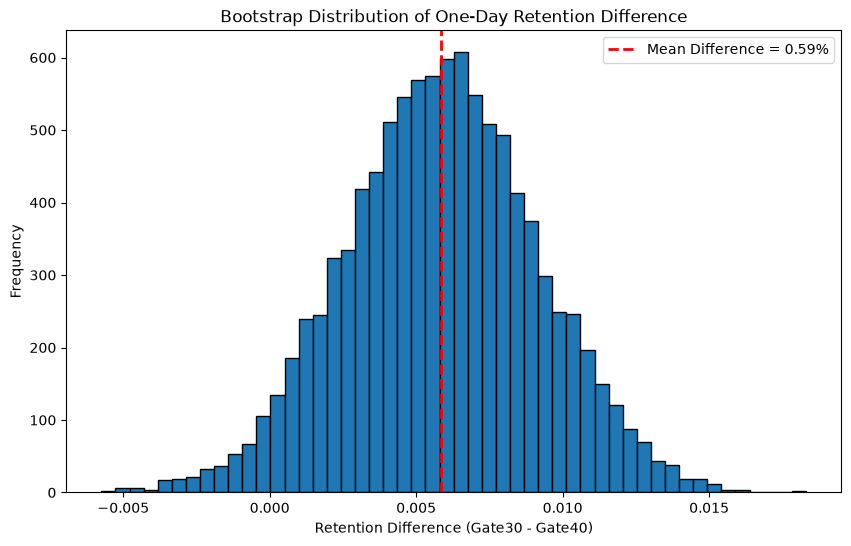

In [6]:
plt.figure(figsize=(10, 6))

plt.hist(
    bootstrap_diffs_1,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    bootstrap_diffs_1.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Difference = {bootstrap_diffs_1.mean()*100:.2f}%"
)

plt.title("Bootstrap Distribution of One-Day Retention Difference")
plt.xlabel("Retention Difference (Gate30 - Gate40)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### 3.4 Bootstrap Confidence Interval

Estimate the 95% bootstrap confidence interval using the percentile method.

The lower and upper bounds correspond to the 2.5th and 97.5th percentiles of the bootstrap distribution.

In [7]:
lower_boot = np.percentile(bootstrap_diffs_1, 2.5)
upper_boot = np.percentile(bootstrap_diffs_1, 97.5)

print(f"Bootstrap Mean Difference : {bootstrap_diffs_1.mean()*100:.2f}%")
print(f"95% Bootstrap CI : ({lower_boot*100:.2f}%, {upper_boot*100:.2f}%)")

Bootstrap Mean Difference : 0.59%
95% Bootstrap CI : (-0.05%, 1.23%)


### 3.5 Interpretation

#### Bootstrap Results

- **Bootstrap Mean Difference:** **0.59%**
- **95% Bootstrap Confidence Interval:** **(-0.05%, 1.23%)**

#### Key Insights

- The bootstrap distribution is approximately bell-shaped and centered around the observed retention difference.
- The bootstrap confidence interval includes **0**, indicating that no difference between the two groups remains a plausible outcome.
- The bootstrap estimates closely match the confidence interval obtained from the classical statistical approach.

#### Business Perspective

The bootstrap analysis reinforces the conclusion that moving the progression gate from Level 30 to Level 40 did **not** produce a statistically reliable change in one-day retention. Both parametric and non-parametric methods lead to the same conclusion.

# 4. Seven-Day Retention Bootstrap

## Objective

Validate the seven-day retention results using bootstrap resampling.

This analysis estimates the sampling distribution of the seven-day retention difference and provides an independent confidence interval to compare with the classical statistical approach.

### 4.1 Prepare the Data

Separate the seven-day retention outcomes for the control and treatment groups.

In [8]:
gate30_7 = df[df["version"] == "gate_30"]["retention_7"]

gate40_7 = df[df["version"] == "gate_40"]["retention_7"]

print(len(gate30_7))
print(len(gate40_7))

44700
45489


### 4.2 Bootstrap Sampling

Generate 10,000 bootstrap samples for the seven-day retention data.

For each bootstrap sample:

1. Sample players with replacement from each experiment group.
2. Compute the seven-day retention rate.
3. Calculate the retention difference (gate_30 − gate_40).
4. Store the difference for analysis.

In [9]:
bootstrap_diffs_7 = []

n_iterations = 10000

for _ in range(n_iterations):

    sample30 = gate30_7.sample(
        n=len(gate30_7),
        replace=True
    )

    sample40 = gate40_7.sample(
        n=len(gate40_7),
        replace=True
    )

    retention30 = sample30.mean()
    retention40 = sample40.mean()

    diff = retention30 - retention40

    bootstrap_diffs_7.append(diff)

bootstrap_diffs_7 = np.array(bootstrap_diffs_7)

print("Bootstrap samples generated:", len(bootstrap_diffs_7))

Bootstrap samples generated: 10000


### 4.3 Visualize the Bootstrap Distribution

Visualize the distribution of the bootstrapped seven-day retention differences.

The distribution illustrates the variability of the estimated long-term treatment effect across repeated simulated experiments.

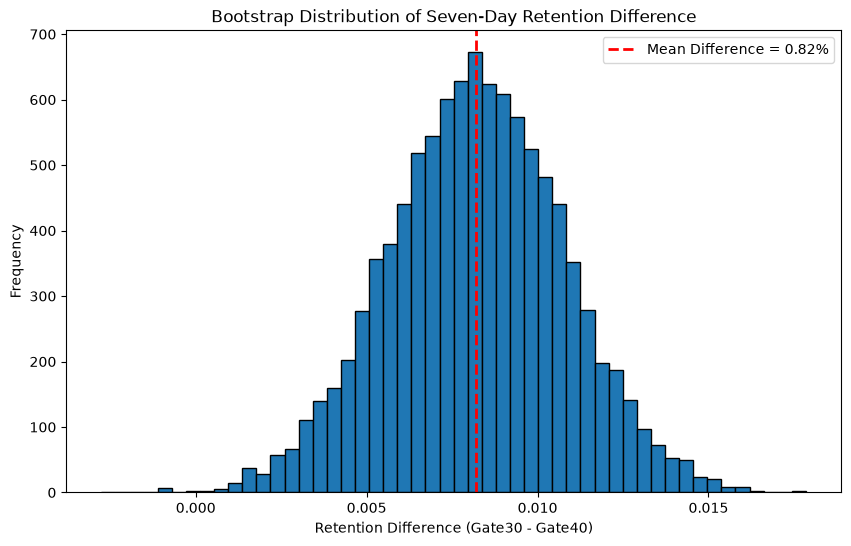

In [10]:
plt.figure(figsize=(10,6))

plt.hist(
    bootstrap_diffs_7,
    bins=50,
    edgecolor="black"
)

plt.axvline(
    bootstrap_diffs_7.mean(),
    color="red",
    linestyle="--",
    linewidth=2,
    label=f"Mean Difference = {bootstrap_diffs_7.mean()*100:.2f}%"
)

plt.title("Bootstrap Distribution of Seven-Day Retention Difference")
plt.xlabel("Retention Difference (Gate30 - Gate40)")
plt.ylabel("Frequency")
plt.legend()

plt.show()

### 4.4 Bootstrap Confidence Interval

Estimate the 95% bootstrap confidence interval for the seven-day retention difference using the percentile method.

In [11]:
lower_boot_7 = np.percentile(bootstrap_diffs_7, 2.5)
upper_boot_7 = np.percentile(bootstrap_diffs_7, 97.5)

print(f"Bootstrap Mean Difference : {bootstrap_diffs_7.mean()*100:.2f}%")
print(f"95% Bootstrap CI : ({lower_boot_7*100:.2f}%, {upper_boot_7*100:.2f}%)")

Bootstrap Mean Difference : 0.82%
95% Bootstrap CI : (0.31%, 1.33%)


### 4.5 Interpretation

#### Bootstrap Results

- **Bootstrap Mean Difference:** **0.82%**
- **95% Bootstrap Confidence Interval:** **(0.31%, 1.33%)**

#### Key Insights

- The bootstrap distribution is approximately bell-shaped and centered around the observed retention difference.
- The bootstrap confidence interval does **not** include 0, indicating a statistically significant difference.
- The bootstrap confidence interval closely matches the confidence interval obtained using the classical statistical approach.

#### Business Perspective

The bootstrap analysis confirms that players assigned to **gate_30** consistently exhibit higher seven-day retention than those assigned to **gate_40**. The agreement between bootstrap and classical inference strengthens confidence that the observed effect is genuine rather than a result of sampling variability.

# 5. Bootstrap vs Classical Comparison

## Objective

Compare the confidence intervals obtained from classical statistical inference and bootstrap resampling.

Agreement between these independent approaches increases confidence in the robustness of the experimental findings.

### 5.1 Comparison of Statistical Methods

The table below summarizes the confidence intervals obtained using both approaches.

In [12]:
comparison = pd.DataFrame({
    "Metric": [
        "Mean Difference",
        "95% Confidence Interval",
        "Statistical Conclusion"
    ],
    "One-Day (Classical)": [
        "0.59%",
        "(-0.06%, 1.24%)",
        "Not Significant"
    ],
    "One-Day (Bootstrap)": [
        "0.59%",
        "(-0.05%, 1.23%)",
        "Not Significant"
    ],
    "Seven-Day (Classical)": [
        "0.82%",
        "(0.31%, 1.33%)",
        "Significant"
    ],
    "Seven-Day (Bootstrap)": [
        "0.82%",
        "(0.31%, 1.33%)",
        "Significant"
    ]
})

comparison

,Metric,One-Day (Classical),One-Day (Bootstrap),Seven-Day (Classical),Seven-Day (Bootstrap)
0,Mean Difference,0.59%,0.59%,0.82%,0.82%
1,95% Confidence Interval,"(-0.06%, 1.24%)","(-0.05%, 1.23%)","(0.31%, 1.33%)","(0.31%, 1.33%)"
2,Statistical Conclusion,Not Significant,Not Significant,Significant,Significant


### 5.2 Interpretation

#### Key Findings

- Classical inference and bootstrap resampling produced nearly identical estimates.
- Both methods reached the same statistical conclusions for one-day and seven-day retention.
- The close agreement indicates that the experimental findings are robust and not sensitive to the choice of statistical method.

#### Business Perspective

Using both parametric and non-parametric approaches provides stronger evidence for decision-making. The consistency across methods increases confidence that the observed differences accurately reflect player behavior.

# 6. Key Takeaways

## Summary

- Bootstrap resampling successfully validated the conclusions obtained from classical hypothesis testing.
- No statistically significant difference was observed in one-day retention.
- A statistically significant improvement in seven-day retention was observed for **gate_30**.
- The bootstrap confidence intervals closely matched the classical confidence intervals, reinforcing the reliability of the results.
- Although statistically significant, the observed improvement remains practically small, suggesting that business decisions should also consider player experience, monetization, and long-term engagement metrics.

## Final Conclusion

Both classical statistical inference and bootstrap validation consistently indicate that maintaining the progression gate at **Level 30** results in better seven-day player retention than moving the gate to **Level 40**.